# 딥러닝 - 기본 MLP + EarlyStopping (PyTorch)

담당: 문희영 (기본 MLP + EarlyStopping)
전처리는 `03_ml_heeyoung.ipynb`와 동일 (days_to_expire는 데이터 누수로 판단해 제외)
공통 규칙: 동일한 integrated_data.csv, 동일한 train/test 분할(test_size=0.2, stratify=y, random_state=42)
기록 항목: 학습 곡선, ROC-AUC, Recall, F1

> 수업에서 사용한 PyTorch 기준으로 구현하며, BatchNorm/Dropout 없이 기본 MLP + EarlyStopping만 적용합니다.


# 1. 데이터 로드

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/processed/integrated_data.csv")
print(df.shape)
df.head(10)

(100000, 22)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,...,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,14.0,22.0,female,7.0,20160119.0,14.0,0.0,1386.0,...,30.0,18.0,0.0,4.0,18397.448,68.0,78.0,11.0,1,1
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,1.0,0.0,NaN,7.0,20151027.0,17.0,0.0,1683.0,...,30.0,27.0,0.0,0.0,0.000,0.0,0.0,NaN,1,0
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,13.0,29.0,male,7.0,20140518.0,26.0,0.0,3754.0,...,30.0,17.0,0.0,55.0,134757.376,529.0,541.0,3.0,1,1
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,1.0,0.0,NaN,4.0,20161214.0,3.0,0.0,450.0,...,30.0,16.0,0.0,65.0,352944.005,1293.0,1312.0,0.0,1,1
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,1.0,0.0,NaN,7.0,20130915.0,20.0,0.0,1980.0,...,30.0,6.0,0.0,8.0,29785.691,106.0,121.0,0.0,1,1
5,lg3zG4deV9LDua90hgftaBHgV97OTYNl7iR0IbJDhFw=,0,15.0,29.0,female,9.0,20090718.0,20.0,0.0,2980.0,...,30.0,53.0,0.0,4.0,10133.685,32.0,27.0,75.0,1,1
6,ia7d0Dw3wYAP8evWEwftFCbw0dWoKkrxQ6BQvruSpcs=,0,13.0,34.0,NaN,9.0,20131023.0,22.0,0.0,3278.0,...,30.0,31.0,0.0,23.0,91863.181,324.0,333.0,9.0,1,1
7,Gh2S7y+rTVK3zHwqtGwnAUFxZ4QZo9JuEX01ykl7sDs=,0,1.0,0.0,NaN,7.0,20160122.0,14.0,0.0,1386.0,...,30.0,21.0,0.0,79.0,904878.545,3754.0,2485.0,0.0,1,1
8,j84nJ8grTvXdE3lBR4IZ7Yb3GXnFwD3WvaiZ5S/drfM=,0,11.0,0.0,NaN,3.0,20131217.0,27.0,3.0,3855.0,...,30.0,3.0,0.0,23.0,38083.585,157.0,125.0,0.0,1,1
9,iXWRSn+9nymKIpbu510N//m87vQcnCYUifuXn/GMqGk=,0,1.0,0.0,NaN,7.0,20160104.0,14.0,0.0,1386.0,...,30.0,3.0,0.0,0.0,0.000,0.0,0.0,NaN,1,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    100000 non-null  object 
 1   is_churn                100000 non-null  int64  
 2   city                    88648 non-null   float64
 3   bd                      88648 non-null   float64
 4   gender                  39831 non-null   object 
 5   registered_via          88648 non-null   float64
 6   registration_init_time  88648 non-null   float64
 7   transaction_count       100000 non-null  float64
 8   cancel_count            100000 non-null  float64
 9   total_payment           100000 non-null  float64
 10  last_auto_renew         99862 non-null   float64
 11  last_is_cancel          99862 non-null   float64
 12  last_plan_days          99862 non-null   float64
 13  days_to_expire          99862 non-null   float64
 14  cancel_on_last_date  

In [3]:
# 컬럼별 결측치 확인
df.isnull().sum()

msno                          0
is_churn                      0
city                      11352
bd                        11352
gender                    60169
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew             138
last_is_cancel              138
last_plan_days              138
days_to_expire              138
cancel_on_last_date         138
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log       18281
has_transaction               0
has_log                       0
dtype: int64

In [4]:
# 이탈 비율 확인 (원본과 일치하는지)
df['is_churn'].value_counts(normalize=True)

is_churn
0    0.91049
1    0.08951
Name: proportion, dtype: float64

In [5]:
# has_transaction / has_log 분포 확인 — 결측 처리 방향 결정에 참고
print(df['has_transaction'].value_counts())
print(df['has_log'].value_counts())

has_transaction
1    99862
0      138
Name: count, dtype: int64
has_log
1    81719
0    18281
Name: count, dtype: int64


# 2. 전처리 (03_ml_heeyoung.ipynb와 동일한 로직 사용)

### 2-1. 범주형 컬럼 확인

In [6]:
# city, registered_via는 숫자로 저장되어 있지만 실제로는 범주형 변수임
print(df['city'].nunique())
print(df['registered_via'].nunique())

21
5


### 2-2. gender 결측치 처리

In [7]:
# gender 결측치를 'Unknown' 카테고리로 채움
df['gender'] = df['gender'].fillna('Unknown')
df['gender'].value_counts()

gender
Unknown    60169
male       20923
female     18908
Name: count, dtype: int64

### 2-3. bd(나이) 이상치 처리

In [8]:
# EDA에서 확인된 기준: 10~80세만 정상, 그 외(0/음수/81세 이상)는 이상치
print(df['bd'].describe())

count    88648.000000
mean        13.497981
std         19.685454
min        -51.000000
25%          0.000000
50%          0.000000
75%         27.000000
max       1820.000000
Name: bd, dtype: float64


In [9]:
# EDA에서 확인된 기준: 10~80세만 정상, 그 외는 이상치로 처리
bd_valid = df['bd'].between(10, 80)

df['bd_is_missing'] = (~bd_valid).astype(int)
median_bd = df.loc[bd_valid, 'bd'].median()
df.loc[~bd_valid, 'bd'] = median_bd

print('중앙값 대체:', median_bd)
print(df['bd_is_missing'].value_counts(normalize=True))

중앙값 대체: 28.0
bd_is_missing
1    0.60424
0    0.39576
Name: proportion, dtype: float64


### 2-4. 거래/로그 없는 고객 처리 (has_transaction, has_log 활용)

In [10]:
# last_auto_renew, last_is_cancel 등은 거래 기록이 없으면(has_transaction=0) NaN
# -1로 채워서 "기록 없음"을 별도 값으로 표시 (0/1과 겹치지 않는 값)
df['last_auto_renew'] = df['last_auto_renew'].fillna(-1)
df['last_is_cancel'] = df['last_is_cancel'].fillna(-1)
df['last_plan_days'] = df['last_plan_days'].fillna(-1)
df['cancel_on_last_date'] = df['cancel_on_last_date'].fillna(-1)

# days_to_expire: '마지막 거래 만료일 - 기준일(2/28)' 파생 컬럼
# -> is_churn 그룹별 분포/음수비율 확인 + LightGBM feature importance 1위 + 제거 시 ROC-AUC 3.77%p 하락 확인됨
# -> 이탈 여부와 사실상 직결된 정보(정답 유출)로 판단해 모델링에서 완전히 제외함
df = df.drop(columns=['days_to_expire'])

# days_since_last_log: 로그가 없는 사람은 "아주 오랫동안 안 들었다"는 의미로 최댓값으로 채움
df['days_since_last_log'] = df['days_since_last_log'].fillna(df['days_since_last_log'].max())

# 처리 후 결측치 재확인
df.isnull().sum()

msno                          0
is_churn                      0
city                      11352
bd                            0
gender                        0
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew               0
last_is_cancel                0
last_plan_days                0
cancel_on_last_date           0
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log           0
has_transaction               0
has_log                       0
bd_is_missing                 0
dtype: int64

### 2-5. 범주형 컬럼 원-핫 인코딩

In [11]:
# city, registered_via 결측치를 별도 카테고리(-1)로 채움
df['city'] = df['city'].fillna(-1)
df['registered_via'] = df['registered_via'].fillna(-1)

df.isnull().sum()

msno                          0
is_churn                      0
city                          0
bd                            0
gender                        0
registered_via                0
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew               0
last_is_cancel                0
last_plan_days                0
cancel_on_last_date           0
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log           0
has_transaction               0
has_log                       0
bd_is_missing                 0
dtype: int64

In [12]:
# city, registered_via, gender 원-핫 인코딩
# drop_first=True: 다중공선성 방지를 위해 각 컬럼당 카테고리 1개는 기준값으로 제외
categorical_cols = ['gender', 'city', 'registered_via']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# registration_init_time은 문자열(날짜) 그대로 모델에 넣을 수 없으므로 제거
df_encoded = df_encoded.drop(columns=['registration_init_time'])

print(df_encoded.shape)
df_encoded.head()

(100000, 46)


,msno,is_churn,bd,transaction_count,cancel_count,total_payment,last_auto_renew,last_is_cancel,last_plan_days,cancel_on_last_date,...,city_18.0,city_19.0,city_20.0,city_21.0,city_22.0,registered_via_3.0,registered_via_4.0,registered_via_7.0,registered_via_9.0,registered_via_13.0
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,22.0,14.0,0.0,1386.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,28.0,17.0,0.0,1683.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,29.0,26.0,0.0,3754.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,28.0,3.0,0.0,450.0,0.0,0.0,30.0,0.0,...,False,False,False,False,False,False,True,False,False,False
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,28.0,20.0,0.0,1980.0,1.0,0.0,30.0,0.0,...,False,False,False,False,False,False,False,True,False,False


# 3. train_test_split

MLP는 입력 스케일에 민감하므로, 트리 모델과 달리 **StandardScaler로 스케일링을 추가**합니다.
먼저 train/test를 공통 규칙으로 나눈 뒤, train을 다시 train/validation으로 분리합니다.
그 다음 **실제 학습용 train 데이터에만 StandardScaler를 fit**하고 validation/test에는 transform만 적용해 데이터 누수를 방지합니다.
최초 train/test 분할 파라미터(test_size, stratify, random_state)는 `03_ml_heeyoung.ipynb`와 동일하게 유지합니다.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X(피처)와 y(타겟) 분리
X = df_encoded.drop(columns=['msno', 'is_churn'])
y = df_encoded['is_churn']

# 1) 공통 규칙으로 train / test 분리
# test_size=0.2, stratify=y(클래스 비율 유지), random_state=42(재현성)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) train 내부에서 train / validation 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

# 3) scaler는 실제 학습용 train에만 fit
# validation / test는 같은 scaler로 transform만 수행
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("train :", X_train_scaled.shape)
print("val   :", X_val_scaled.shape)
print("test  :", X_test_scaled.shape)


train : (64000, 44)
val   : (16000, 44)
test  : (20000, 44)


# 4. 기본 MLP 모델 구성 + EarlyStopping

가장 단순한 구조(BatchNorm/Dropout 없음)의 MLP에 EarlyStopping만 적용한 베이스라인입니다.
다른 팀원들이 담당하는 BatchNorm / Dropout / BatchNorm+Dropout 버전과 비교할 기준선 역할을 합니다.

PyTorch에서는 `BCEWithLogitsLoss`를 사용하므로 마지막 층에 Sigmoid를 넣지 않고, 평가 시점에 `torch.sigmoid()`를 적용합니다.


In [14]:
import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# 위 3번 셀에서 이미 train / validation / test 분리와 스케일링 완료
y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

# Tensor 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

# DataLoader
BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 기본 MLP: BatchNorm / Dropout 없음
class BaselineMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

n_features = X_train_scaled.shape[1]
model = BaselineMLP(n_features).to(device)

print(model)
print("학습 파라미터 수:", sum(p.numel() for p in model.parameters() if p.requires_grad))


device: cpu
BaselineMLP(
  (network): Sequential(
    (0): Linear(in_features=44, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
학습 파라미터 수: 5505


In [15]:
# 클래스 불균형 대응
# ML 노트북의 scale_pos_weight와 같은 취지로 양성 클래스에 더 큰 가중치 적용
# 실제 학습에 사용하는 y_train만 기준으로 계산
neg = (y_train_np == 0).sum()
pos = (y_train_np == 1).sum()
pos_weight_value = neg / pos

print("neg:", neg)
print("pos:", pos)
print("pos_weight:", pos_weight_value)

# BCEWithLogitsLoss의 pos_weight는 양성(이탈=1) 클래스에 적용됨
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


neg: 58271
pos: 5729
pos_weight: 10.171234072263921


In [16]:
from sklearn.metrics import roc_auc_score

EPOCHS = 100
PATIENCE = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": []
}

best_val_loss = float("inf")
best_model_state = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    # -------------------------
    # 1) Train
    # -------------------------
    model.train()

    train_loss_sum = 0.0
    train_probs = []
    train_targets = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)

        probs = torch.sigmoid(logits)
        train_probs.extend(probs.detach().cpu().numpy().ravel())
        train_targets.extend(yb.detach().cpu().numpy().ravel())

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_auc = roc_auc_score(train_targets, train_probs)

    # -------------------------
    # 2) Validation
    # -------------------------
    model.eval()

    val_loss_sum = 0.0
    val_probs = []
    val_targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss_sum += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy().ravel())
            val_targets.extend(yb.cpu().numpy().ravel())

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_auc = roc_auc_score(val_targets, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_auc={train_auc:.4f} | val_auc={val_auc:.4f}"
    )

    # -------------------------
    # 3) EarlyStopping
    # -------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        patience_count = 0
    else:
        patience_count += 1

        if patience_count >= PATIENCE:
            print(f"EarlyStopping: epoch {epoch}에서 학습 종료")
            break

# 가장 좋은 validation loss의 가중치 복원
model.load_state_dict(best_model_state)
model.to(device)

print("Best val_loss:", best_val_loss)


Epoch 001 | train_loss=0.9305 | val_loss=0.8657 | train_auc=0.8105 | val_auc=0.8361
Epoch 002 | train_loss=0.8583 | val_loss=0.8592 | train_auc=0.8342 | val_auc=0.8374
Epoch 003 | train_loss=0.8521 | val_loss=0.8567 | train_auc=0.8390 | val_auc=0.8393
Epoch 004 | train_loss=0.8476 | val_loss=0.8507 | train_auc=0.8418 | val_auc=0.8432
Epoch 005 | train_loss=0.8445 | val_loss=0.8564 | train_auc=0.8434 | val_auc=0.8396
Epoch 006 | train_loss=0.8414 | val_loss=0.8519 | train_auc=0.8453 | val_auc=0.8412
Epoch 007 | train_loss=0.8364 | val_loss=0.8521 | train_auc=0.8480 | val_auc=0.8400
Epoch 008 | train_loss=0.8349 | val_loss=0.8595 | train_auc=0.8486 | val_auc=0.8372
Epoch 009 | train_loss=0.8327 | val_loss=0.8518 | train_auc=0.8495 | val_auc=0.8405
EarlyStopping: epoch 9에서 학습 종료
Best val_loss: 0.8507054009437561


# 5. 학습 곡선 (Loss / AUC)

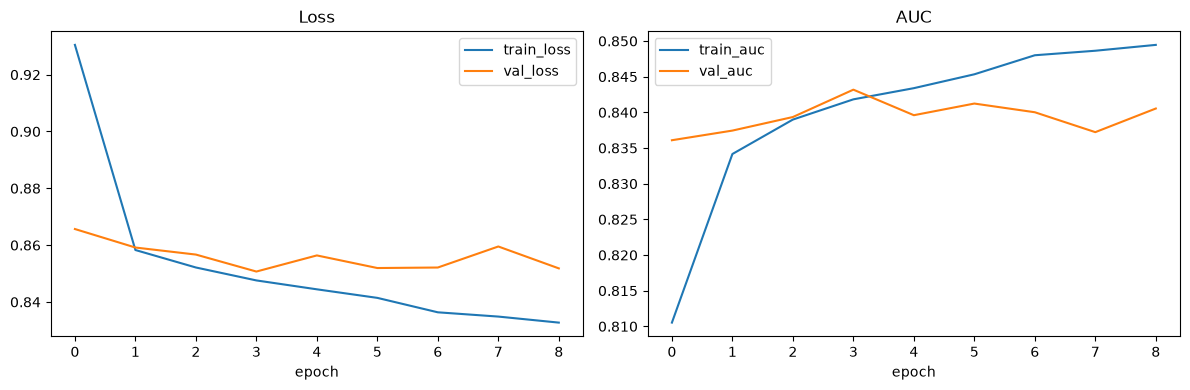

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train_auc")
axes[1].plot(history["val_auc"], label="val_auc")
axes[1].set_title("AUC")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


# 6. 평가 (ROC-AUC, Recall, F1)

In [18]:
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

test_probs = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        test_probs.extend(probs.cpu().numpy().ravel())
        test_targets.extend(yb.numpy().ravel())

y_pred_proba = np.array(test_probs)
y_test_eval = np.array(test_targets).astype(int)

# 팀 공통 기준: threshold=0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test_eval, y_pred_proba)
recall = recall_score(y_test_eval, y_pred)
f1 = f1_score(y_test_eval, y_pred)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1     : {f1:.4f}")
print()
print(classification_report(y_test_eval, y_pred))
print(confusion_matrix(y_test_eval, y_pred))


ROC-AUC: 0.8338
Recall : 0.6592
F1     : 0.5087

              precision    recall  f1-score   support

           0       0.96      0.91      0.94     18210
           1       0.41      0.66      0.51      1790

    accuracy                           0.89     20000
   macro avg       0.69      0.78      0.72     20000
weighted avg       0.92      0.89      0.90     20000

[[16541  1669]
 [  610  1180]]


# 7. 결과 요약

### 최종 성능
- ROC-AUC: **0.8338**
- Recall: **0.6592**
- F1-score: **0.5087**
- EarlyStopping: **9 epoch에서 학습 종료**
- Best validation loss: **0.8507**

### 참고
- 프레임워크: PyTorch
- 전처리는 `03_ml_heeyoung.ipynb`와 동일 (`days_to_expire` 제외)
- train/test 분할 후 train을 다시 train/validation으로 분리
- `StandardScaler`는 실제 학습용 train에만 fit, validation/test에는 transform만 적용
- 기본 MLP 구조: **64 → 32 → 16 → 1** (BatchNorm / Dropout 없음)
- 클래스 불균형 대응: `BCEWithLogitsLoss(pos_weight=neg/pos)`
- EarlyStopping: `val_loss` 기준, `patience=5`, best weight 복원
- 평가 threshold: **0.5**
- 위 결과와 학습 곡선을 `05_dl_comparison.ipynb` 취합 시 사용
